In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import backtrader as bt

/Users/dipalshah/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [11]:
stocks = ["NVDA", "PLTR", "TTWO", "AMD", "META", "CCL", "AAPL", "COST"]
stock_data = yf.download(stocks, period = "max", interval = "1d", group_by = "tickers")

[*********************100%%**********************]  8 of 8 completed


In [13]:
stock_data = stock_data.dropna()

In [15]:
stock_data.to_csv("new_data.csv")

In [60]:
stock_data = pd.read_csv("new_data.csv", header = [0, 1], index_col = 0)
stock_data.index = pd.to_datetime(stock_data.index)

In [61]:
stock_data

PLTR                                                  \
                  Open        High         Low       Close   Adj Close   
Date                                                                     
2020-09-30   10.000000   11.410000    9.110000    9.500000    9.500000   
2020-10-01    9.690000   10.100000    9.230000    9.460000    9.460000   
2020-10-02    9.060000    9.280000    8.940000    9.200000    9.200000   
2020-10-05    9.430000    9.490000    8.920000    9.030000    9.030000   
2020-10-06    9.040000   10.180000    8.900000    9.900000    9.900000   
...                ...         ...         ...         ...         ...   
2025-02-05  101.779999  103.570000   99.320000  101.360001  101.360001   
2025-02-06  101.089996  111.544998  100.260002  111.279999  111.279999   
2025-02-07  111.660004  116.300003  110.449997  110.849998  110.849998   
2025-02-10  112.029999  116.760002  108.720001  116.650002  116.650002   
2025-02-11  116.500000  118.660004  112.099998  112.620003  112.620003   

                               NVDA                                      ...  \
                 Volume        Open        High         Low       Close  ...   
Date                                                                     ...   
2020-09-30  338584400.0   13.157500   13.622500   13.150250   13.530500  ...   
2020-10-01  124297600.0   13.758000   13.762750   13.460750   13.614500  ...   
2020-10-02   55018300.0   13.225000   13.519500   13.051000   13.062250  ...   
2020-10-05   36316900.0   13.236000   13.644250   13.222750   13.642500  ...   
2020-10-06   90864000.0   13.830000   14.142000   13.665000   13.736500  ...   
...                 ...         ...         ...         ...         ...  ...   
2025-02-05   90628300.0  121.760002  125.000000  120.760002  124.830002  ...   
2025-02-06  128217500.0  127.419998  128.770004  125.209999  128.679993  ...   
2025-02-07  143795400.0  129.220001  130.369995  125.000000  129.839996  ...   
2025-02-10   99938100.0  130.089996  135.000000  129.960007  133.570007  ...   
2025-02-11   93927900.0  132.580002  134.479996  131.020004  132.800003  ...   

                  CCL                                           COST  \
                  Low      Close  Adj Close      Volume         Open   
Date                                                                   
2020-09-30  15.110000  15.180000  15.180000  44374800.0   352.559998   
2020-10-01  14.700000  15.030000  15.030000  28158400.0   356.260010   
2020-10-02  14.230000  15.160000  15.160000  30936100.0   354.730011   
2020-10-05  14.800000  14.960000  14.960000  22169300.0   355.329987   
2020-10-06  15.120000  15.190000  15.190000  43724300.0   361.899994   
...               ...        ...        ...         ...          ...   
2025-02-05  26.740000  27.190001  27.190001  13072200.0  1020.000000   
2025-02-06  26.940001  27.440001  27.440001  14071200.0  1050.000000   
2025-02-07  26.670000  26.750000  26.750000  15149200.0  1047.000000   
2025-02-10  26.010000  26.100000  26.100000  14713100.0  1052.000000   
2025-02-11  25.330000  25.610001  25.610001  14030500.0  1059.910034   

                                                                           
                   High          Low        Close    Adj Close     Volume  
Date                                                                       
2020-09-30   357.700012   351.170013   355.000000   328.032898  2525800.0  
2020-10-01   359.690002   354.820007   358.459991   331.230103  2053000.0  
2020-10-02   357.839996   352.850006   355.010010   328.042267  2125000.0  
2020-10-05   358.980011   355.329987   358.579987   331.340973  2093500.0  
2020-10-06   363.000000   357.040009   358.350006   331.128448  2760400.0  
...                 ...          ...          ...          ...        ...  
2025-02-05  1043.089966  1020.000000  1042.880005  1041.729004  2047600.0  
2025-02-06  1063.000000  1044.199951  1050.989990  1049.829956  2218000.0  
2025-02-07  105

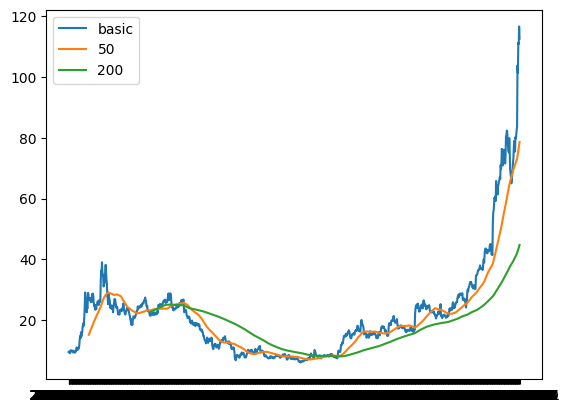

In [ ]:
data = stock_data[('PLTR', "Close")]
data50SMA = data.rolling(50).mean()
data200SMA = data.rolling(200).mean()

plt.plot(data, label = "basic")
plt.plot(data50SMA, label = "50")
plt.plot(data200SMA, label = "200")
plt.legend()
plt.show()

In [63]:
for stock in stocks:
    data = stock_data[(stock, "Close")]
    data50SMA = data.rolling(50).mean()
    data200SMA = data.rolling(200).mean()

    stock_data[(stock, "SMA50")] = data50SMA
    stock_data[(stock, "SMA200")] = data200SMA

In [ ]:
signals = pd.DataFrame({"date": stock_data.index}).set_index("date")

for stock in stocks:
    data50SMA = stock_data[(stock, "SMA50")]
    data200SMA = stock_data[(stock, "SMA200")]

    signal = 2 * (data50SMA > data200SMA) - 1

    signals[stock] = signal

In [73]:
signals["TTWO"]

date
2020-09-30    0
2020-10-01    0
2020-10-02    0
2020-10-05    0
2020-10-06    0
             ..
2025-02-05    0
2025-02-06    0
2025-02-07    0
2025-02-10    0
2025-02-11    0
Name: TTWO, Length: 1097, dtype: int64

In [75]:
class Golden_Cross_Trader(bt.Strategy):

    def __init__(self):
        self.trading_logic = signals


    def next(self):
        dt = self.datas[0].datetime.date(0)
        dt = pd.to_datetime(dt)

        if dt in self.trading_logic.index:
            for i, stock in enumerate(stocks):
                signal = self.trading_logic.loc[dt, stock]

                self.order_target_percent(data = self.datas[i], target = .125 * signal)


In [76]:
cerebro = bt.Cerebro()

for stock in stocks:
    feed = bt.feeds.PandasData(dataname = stock_data[stock])
    cerebro.adddata(data = feed)

cerebro.broker.set_cash(10_000)
cerebro.addstrategy(Golden_Cross_Trader)

cerebro.run()